# Reverse Process Test

In [1]:
import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from typing import Tuple
import yaml
from pathlib import Path
from datetime import datetime
import numpy as np

# Parameters to set

In [52]:
# Set the following parameters
sde_type = "subVP"
num_steps = 1000
batch_size = 1
VAE_SCALE_FACTOR = 0.18215

cfg = {
    "sde_type": sde_type,
    "N": num_steps, 
    "vae_scale_factor" : VAE_SCALE_FACTOR
}

In [81]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
weights_dir = root_dir.joinpath('checkpoints','weights')
model_dir = root_dir.joinpath('src','model')
yaml_file_path = root_dir.joinpath('experiments','base_config.yaml')


# Making packages importable
sys.path.append(str(root_dir))

In [ ]:
weights_name = 'LDM_final_T1000_LR00005_E100_SA_ts20251220_131911.pth' 

In [82]:
from src.utils import WIP_SDE, WIP_processes
from src.models import components
from src.models import UNet


importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)

# UNet = unet_model.UNet
# Unet = unet_base.Unet
UNet = UNet.UNet
from src.utils.WIP_SDE import VESDE, SubVPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
#from src.models.unet_model import UNet


In [73]:
diffusion = Diffusion_Processes(cfg)
diffusion.sde_type

'subvp'

In [26]:
from diffusers import UNet2DModel
model_id = "google/ncsnpp-celebahq-256"
model = UNet2DModel.from_pretrained(model_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)
model.eval()


An error occurred while trying to fetch google/ncsnpp-celebahq-256: google/ncsnpp-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Some weights of the model checkpoint at google/ncsnpp-celebahq-256 were not used when initializing UNet2DModel: 
 ['time_proj.W']


Using device: cuda


UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): GaussianFourierProjection()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=256, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x SkipDownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (resnet_down): ResnetBlock2D(
        (norm1): GroupNorm

# Weights to test (Our Model)

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the REAL Unet model from unet_model.py
print("Instantiating UNet model...")
model = UNet(in_channels=4, out_channels=4).to(device)
model

Using device: cuda
Instantiating UNet model...


UNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=64, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (input_conv): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0-1): 2 x ResBlock(
      (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Sequential(
        (0): SiLU()
        (1): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU()
      (dropout): Dropout(p=0.1, inplace=False)
      (shortcut): Identity()
    )
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ResBlock(
      (norm1): GroupNorm(32, 64, eps=1e-05, affine=Tr

In [79]:
def _extract_state_dict(ckpt):
    for k in ("state_dict", "model", "ema", "model_state_dict"):
        if isinstance(ckpt, dict) and k in ckpt and isinstance(ckpt[k], dict):
            return ckpt[k]
    return ckpt

def _strip_prefixes(sd: dict) -> dict:
    if any(k.startswith("module.") for k in sd):
        sd = {k.split("module.", 1)[1] if k.startswith("module.") else k: v for k, v in sd.items()}
    if all(k.startswith("unet.") for k in sd):
        sd = {k[len("unet."):]: v for k, v in sd.items()}
    return sd

def load_model_from_local(model: nn.Module, ckpt_path: str, device: torch.device) -> bool:
    """Load checkpoint from local filesystem instead of Google Drive."""
    if not os.path.isfile(ckpt_path):
        print(f"Error: Checkpoint not found at {ckpt_path}")
        return False
    print(f"Loading model weights from {ckpt_path} ...")

    try:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    except Exception as e:
        print(f"[torch.load] failed: {e}")
        return False

    sd = _extract_state_dict(ckpt)
    sd = _strip_prefixes(sd)

    model_keys = set(model.state_dict().keys())
    filtered = {k: v for k, v in sd.items() if k in model_keys}

    dropped = sorted(k for k in sd.keys() if k not in model_keys)
    if dropped:
        print(f"Dropping {len(dropped)} unexpected keys (showing up to 8):")
        for k in dropped[:8]:
            print("  ", k)
        if len(dropped) > 8:
            print("  ...")

    res = model.load_state_dict(filtered, strict=False)
    print(f"Loaded. missing={len(res.missing_keys)} unexpected={len(res.unexpected_keys)}")

    model.to(device).eval()
    return True

In [84]:
# --- 3. Load Weights ---
ckpt_path = weights_dir.joinpath(weights_name)
load_model_from_local(model, ckpt_path, device)
ckpt_path

Loading model weights from c:\Users\marco\Desktop\Magistrale\ERASMUS\COURSES TUM\Practicals\Hands on Generative AI\Project\Hands-on-Generative-AI\checkpoints\weights\LDM_final_T1000_LR00005_E10_SA_ts20251220_123154.pth ...
Dropping 280 unexpected keys (showing up to 8):
   down_blocks.10.shortcut.bias
   down_blocks.10.shortcut.weight
   down_blocks.11.attention.norm.bias
   down_blocks.11.attention.norm.weight
   down_blocks.11.attention.proj_out.bias
   down_blocks.11.attention.proj_out.weight
   down_blocks.11.attention.qkv.weight
   down_blocks.11.conv1.bias
  ...


RuntimeError: Error(s) in loading state_dict for UNet:
	size mismatch for down_blocks.3.conv1.weight: copying a param with shape torch.Size([64, 64, 3, 3]) from checkpoint, the shape in current model is torch.Size([128, 64, 3, 3]).
	size mismatch for down_blocks.3.conv1.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for down_blocks.3.time_proj.1.weight: copying a param with shape torch.Size([128, 256]) from checkpoint, the shape in current model is torch.Size([256, 256]).
	size mismatch for down_blocks.3.time_proj.1.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for down_blocks.3.norm2.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for down_blocks.3.norm2.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in c

In [30]:
# 2. Define the Wrapper (Fixes the TypeError)
def model_fn(x, t):
    # Diffusers expects t to be shape (B,) or a scalar, usually handles it fine.
    with torch.no_grad():
        out = model(x, t)
            
    # Extract the actual tensor from the output object
    if hasattr(out, 'sample'):
        return out.sample
    return out[0]


In [31]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(next(model.parameters()).device).eval()
VAE_SCALE_FACTOR = cfg['vae_scale_factor']
VAE_SCALE_FACTOR

0.18215

In [32]:


def decode_from_latent(latents: torch.Tensor):
    """Converte latenti in pixel [0, 1]."""
    latents = latents / VAE_SCALE_FACTOR
    with torch.no_grad():
        image = vae.decode(latents).sample
    return (image / 2 + 0.5).clamp(0, 1)

This is our SDE: <src.utils.WIP_SDE.SubVPSDE object at 0x0000020A3ABDE510>
This is the value of T: 1.0
Check prior subvp: Mean = -0.0007389336824417114, Std = 0.9741252064704895
[reverse step 901/1000 | i=900 | t=0.9000]
mean=0.0277, std=1.0627, min=-3.8079, max=3.8342
Time of last 100 steps: 1.6453232765197754. Time remaining 16.453232765197754.



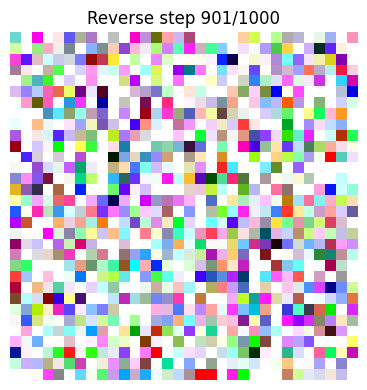

[reverse step 801/1000 | i=800 | t=0.8000]
mean=0.0415, std=1.1701, min=-4.6814, max=4.3376
Time of last 100 steps: 1.5684950351715088. Time remaining 31.369900703430176.



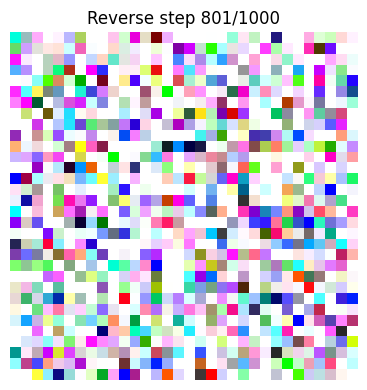

[reverse step 701/1000 | i=700 | t=0.7000]
mean=0.0990, std=1.2661, min=-4.3657, max=4.9171
Time of last 100 steps: 1.5579516887664795. Time remaining 46.738550662994385.



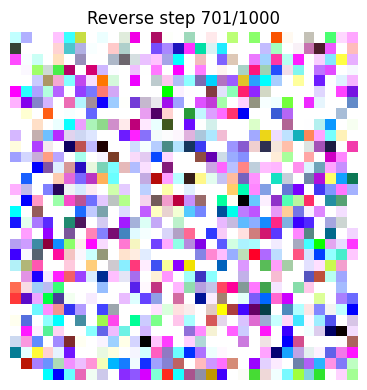

[reverse step 601/1000 | i=600 | t=0.6000]
mean=0.1469, std=1.4331, min=-5.1911, max=5.3272
Time of last 100 steps: 1.5801751613616943. Time remaining 63.20700645446777.



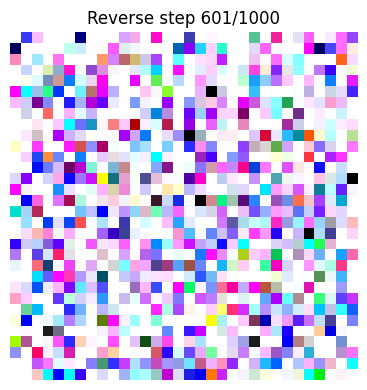

[reverse step 501/1000 | i=500 | t=0.5000]
mean=0.2245, std=1.6234, min=-4.6907, max=5.9019
Time of last 100 steps: 1.6441895961761475. Time remaining 82.20947980880737.



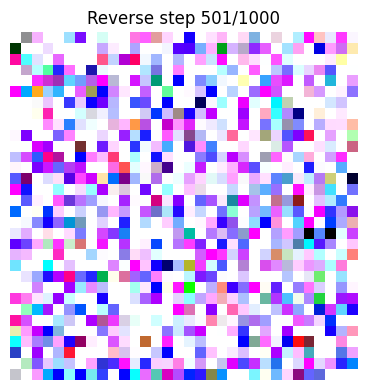

[reverse step 401/1000 | i=400 | t=0.4000]
mean=0.3150, std=1.8107, min=-4.9112, max=6.5610
Time of last 100 steps: 1.607184886932373. Time remaining 96.43109321594238.



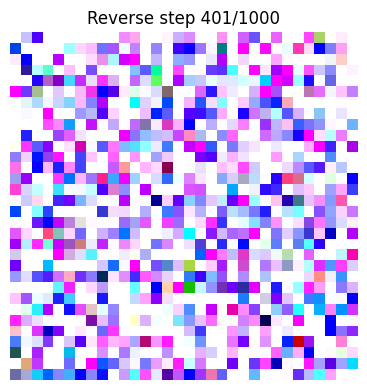

[reverse step 301/1000 | i=300 | t=0.3000]
mean=0.3853, std=1.9759, min=-5.1163, max=7.2872
Time of last 100 steps: 1.608086109161377. Time remaining 112.56602764129639.



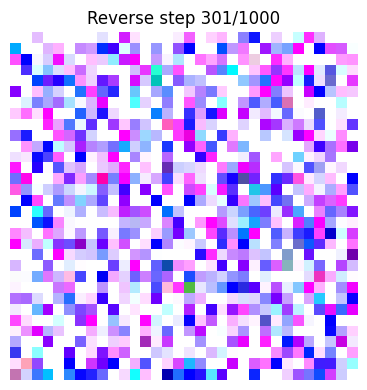

[reverse step 201/1000 | i=200 | t=0.2000]
mean=0.4458, std=2.0801, min=-5.3069, max=7.0949
Time of last 100 steps: 1.5884206295013428. Time remaining 127.07365036010742.



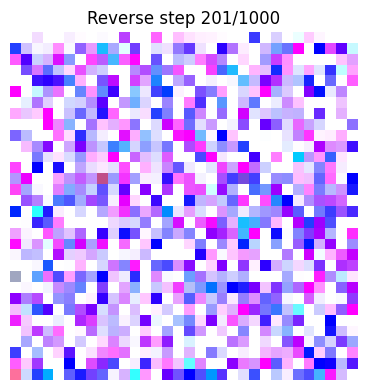

[reverse step 101/1000 | i=100 | t=0.1000]
mean=0.4829, std=2.1311, min=-4.6636, max=6.9829
Time of last 100 steps: 1.6159460544586182. Time remaining 145.43514490127563.



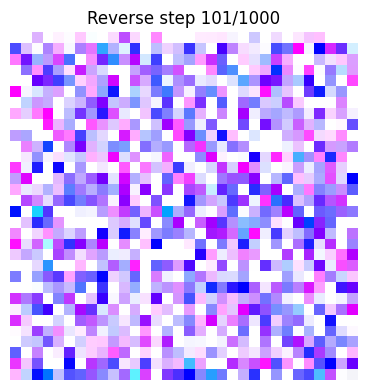

[reverse step 15/1000 | i=14 | t=0.0140]
mean=0.4939, std=2.1417, min=-4.4692, max=6.7245
Time of last 100 steps: 1.4295310974121094. Time remaining 141.52357864379883.



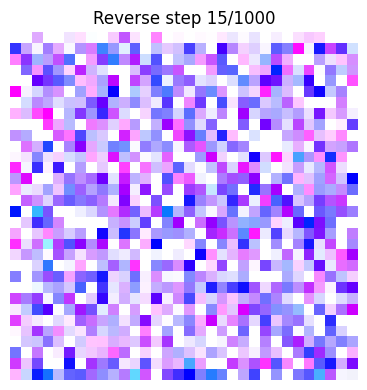

[reverse step 14/1000 | i=13 | t=0.0130]
mean=0.4939, std=2.1418, min=-4.4683, max=6.7236
Time of last 100 steps: 0.051796674728393555. Time remaining 5.127870798110962.



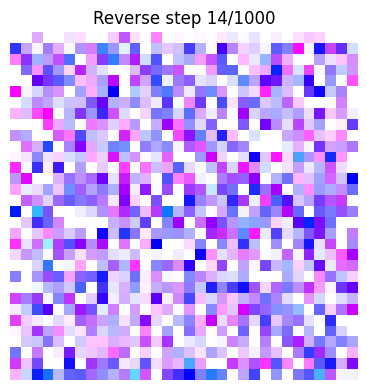

[reverse step 13/1000 | i=12 | t=0.0120]
mean=0.4939, std=2.1418, min=-4.4665, max=6.7249
Time of last 100 steps: 0.0502772331237793. Time remaining 4.97744607925415.



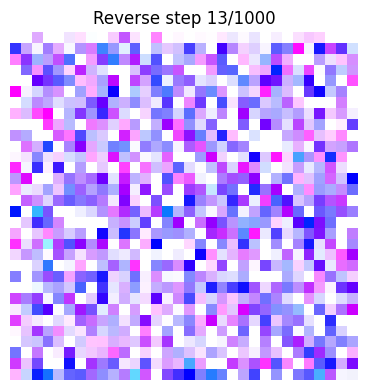

[reverse step 12/1000 | i=11 | t=0.0110]
mean=0.4939, std=2.1419, min=-4.4680, max=6.7251
Time of last 100 steps: 0.05285358428955078. Time remaining 5.232504844665527.



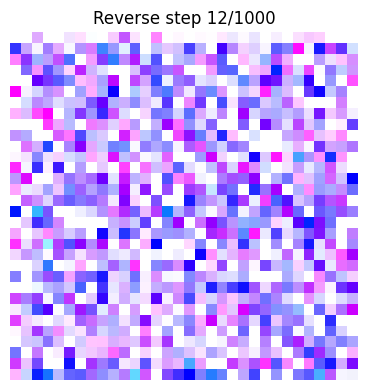

[reverse step 11/1000 | i=10 | t=0.0100]
mean=0.4939, std=2.1419, min=-4.4672, max=6.7229
Time of last 100 steps: 0.04621100425720215. Time remaining 4.574889421463013.



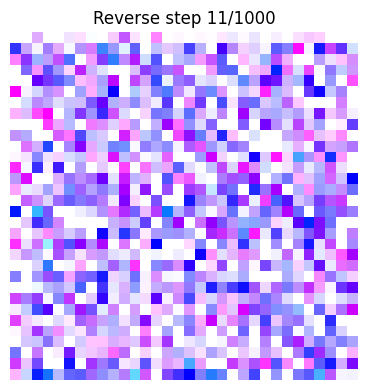

[reverse step 10/1000 | i=9 | t=0.0090]
mean=0.4940, std=2.1419, min=-4.4662, max=6.7232
Time of last 100 steps: 0.05204510688781738. Time remaining 5.204510688781738.



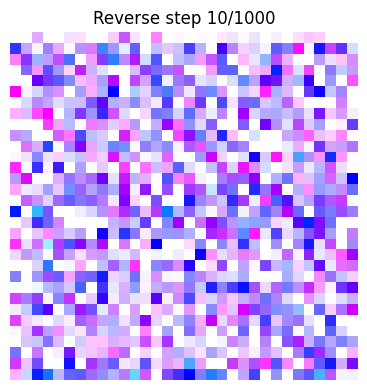

[reverse step 9/1000 | i=8 | t=0.0080]
mean=0.4940, std=2.1419, min=-4.4649, max=6.7242
Time of last 100 steps: 0.0476377010345459. Time remaining 4.76377010345459.



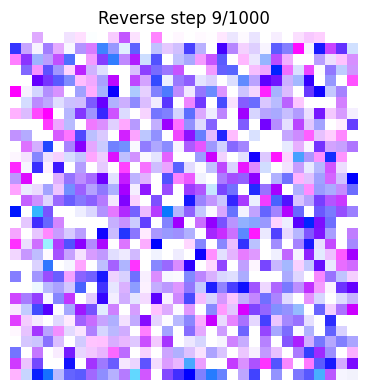

[reverse step 8/1000 | i=7 | t=0.0070]
mean=0.4940, std=2.1419, min=-4.4651, max=6.7240
Time of last 100 steps: 0.05118703842163086. Time remaining 5.118703842163086.



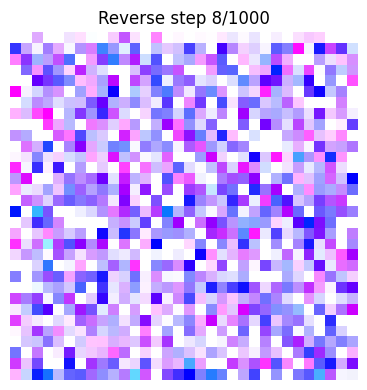

[reverse step 7/1000 | i=6 | t=0.0060]
mean=0.4941, std=2.1420, min=-4.4642, max=6.7240
Time of last 100 steps: 0.04381155967712402. Time remaining 4.381155967712402.



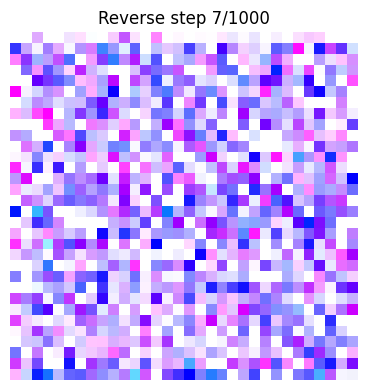

[reverse step 6/1000 | i=5 | t=0.0050]
mean=0.4941, std=2.1420, min=-4.4637, max=6.7230
Time of last 100 steps: 0.05138516426086426. Time remaining 5.138516426086426.



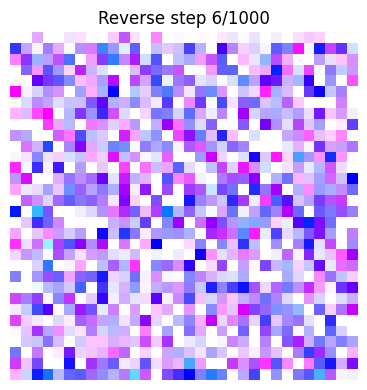

[reverse step 5/1000 | i=4 | t=0.0040]
mean=0.4941, std=2.1420, min=-4.4632, max=6.7229
Time of last 100 steps: 0.06286072731018066. Time remaining 6.286072731018066.



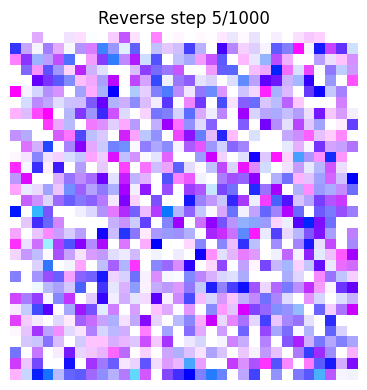

[reverse step 4/1000 | i=3 | t=0.0030]
mean=0.4941, std=2.1420, min=-4.4623, max=6.7224
Time of last 100 steps: 0.053284406661987305. Time remaining 5.3284406661987305.



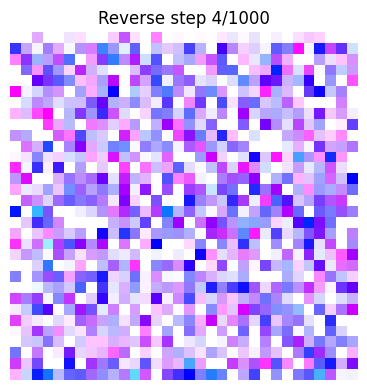

[reverse step 3/1000 | i=2 | t=0.0020]
mean=0.4941, std=2.1420, min=-4.4621, max=6.7221
Time of last 100 steps: 0.040862321853637695. Time remaining 4.0862321853637695.



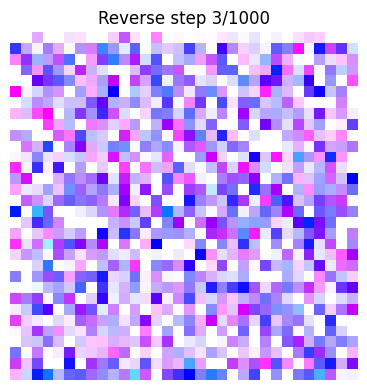

[reverse step 2/1000 | i=1 | t=0.0010]
mean=0.4941, std=2.1420, min=-4.4622, max=6.7218
Time of last 100 steps: 0.05710887908935547. Time remaining 5.710887908935547.



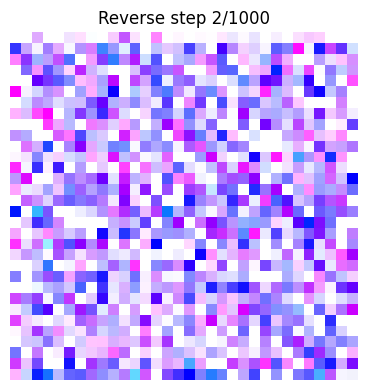

[reverse step 1/1000 | i=0 | t=0.0000]
mean=0.4941, std=2.1421, min=-4.4624, max=6.7222
Time of last 100 steps: 0.04224061965942383. Time remaining 4.224061965942383.



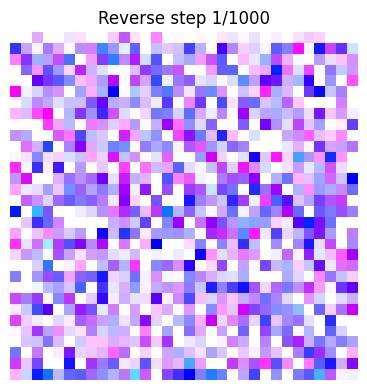

In [57]:
# 3. Run Sampling (Fixes the AttributeError via the class update)
samples = diffusion.reverse_process(
    model=model_fn,             
    shape=(batch_size, 4, 32, 32),
    num_steps=cfg.get('N', 1000),
    probability_flow=False,
    device=device                # Pass device explicitly
)

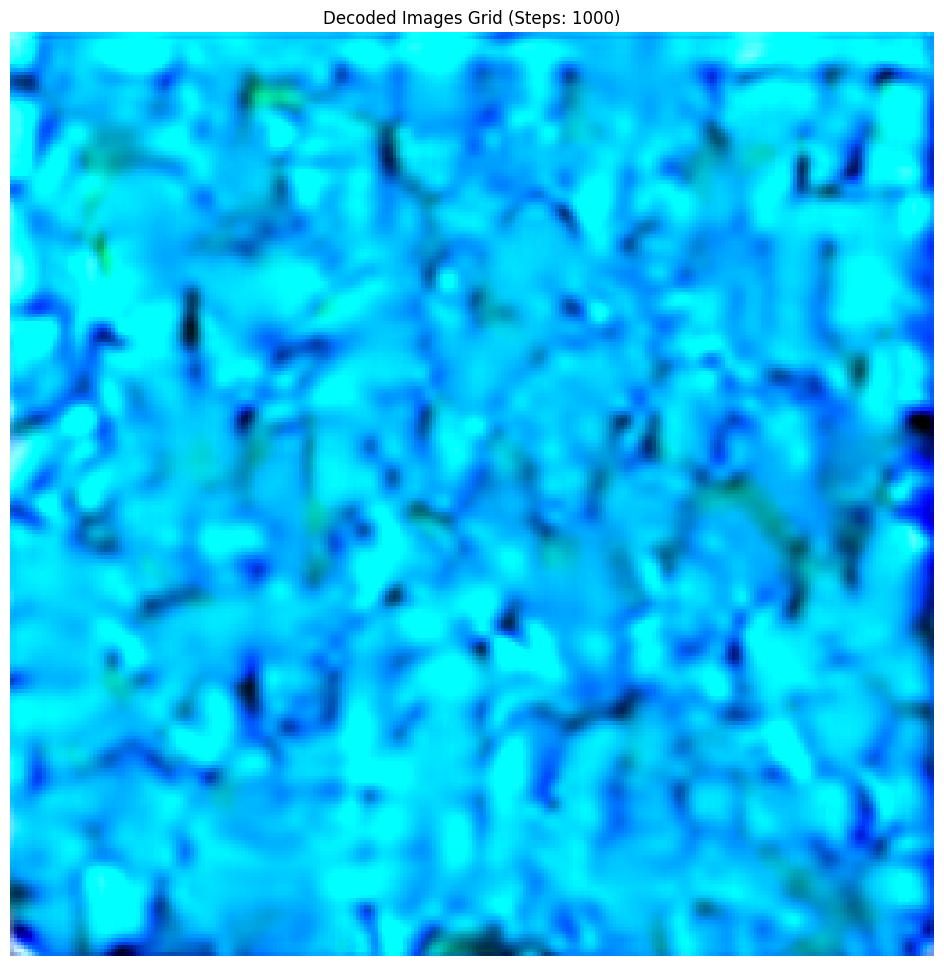

In [58]:
decoded_images = []

# --- 1. Decodifica tutte le immagini e salva in una lista ---
for latent in samples:
    latent = latent.to(next(vae.parameters()).device, dtype=torch.float32).unsqueeze(0)
    decoded = decode_from_latent(latent)  # [1, C, H, W]
    decoded_images.append(decoded[0])      # Rimuovi dimensione batch

# --- 2. Crea un batch da lista di tensori ---
decoded_batch = torch.stack(decoded_images)  # [B, C, H, W]
# --- 3. Crea griglia ---
grid = torchvision.utils.make_grid(decoded_batch, nrow=4, normalize=True, value_range=(0, 1))

# --- 4. Visualizza e salva ---
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu())  # [H, W, C]
plt.axis("off")
plt.title(f"Decoded Images Grid (Steps: {cfg['N']})")

# Salva la griglia
plt.show()


Sample stats: Min=-0.89, Max=0.77, Mean=-0.01


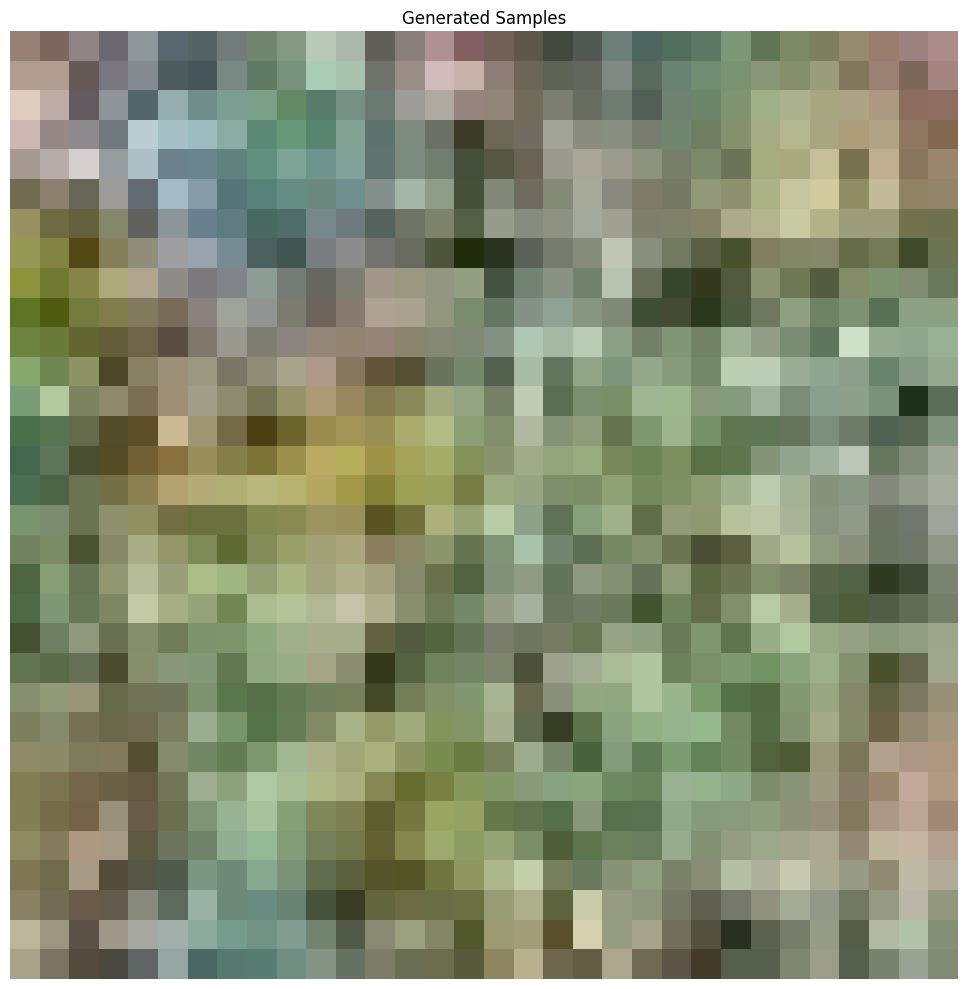

In [62]:
def show_samples(samples):
    # 1. Ensure we are on CPU
    samples_vis = samples.detach().cpu()
    
    # 2. Inspect statistics (Crucial for debugging!)
    print(f"Sample stats: Min={samples_vis.min():.2f}, Max={samples_vis.max():.2f}, Mean={samples_vis.mean():.2f}")
    
    # 3. Robust Normalization
    # SDE models often output values outside [-1, 1] before the final step.
    # If strict [-1, 1] is expected:
    samples_vis = samples_vis.clamp(-1.0, 1.0)
    samples_vis = (samples_vis + 1.0) / 2.0
    
    # 4. Create Grid
    # nrow=int(np.sqrt(batch_size)) automatically makes a square grid
    grid = torchvision.utils.make_grid(samples_vis, nrow=int(np.sqrt(samples_vis.shape[0])), padding=2)
    
    # 5. Permute for Matplotlib
    np_grid = grid.permute(1, 2, 0).numpy()
    
    # 6. Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(np_grid)
    plt.axis("off")
    plt.title("Generated Samples")
    plt.tight_layout()
    plt.show()

# Run the visualization
show_samples(samples)